# 聚类

## K-means

In [1]:
# 1. 导包
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
import matplotlib.pyplot as plt

# 2. 生成模拟数据
# n_samples : 样本数量
# n_features : 特征数量
# centers : 聚类中心数量
# cluster_std : 簇内标准差
X, _ = make_blobs(n_samples = 300, n_features = 2, centers = 3, cluster_std = 1.0, random_state = 42)

In [2]:
# 3. 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. 遍历不同的 k 值, 计算 SSE 与 SC
# SSE : 误差平方和 (簇内样本到质心的距离平方和), 即 KMeans 的 inertia_
# SC  : 轮廓系数 (silhouette_score), 取值范围 [-1, 1], 越大越好
k_range = range(2, 11)
sse_list = []
sc_list = []

for k in k_range:
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = km.fit_predict(X_scaled)
    sse_list.append(km.inertia_)
    sc_list.append(silhouette_score(X_scaled, labels))
    print(f"k = {k}, SSE = {km.inertia_:.2f}, SC = {silhouette_score(X_scaled, labels):.4f}")

k = 2, SSE = 187.80, SC = 0.6875
k = 3, SSE = 18.26, SC = 0.8482
k = 4, SSE = 15.46, SC = 0.6795
k = 5, SSE = 12.72, SC = 0.5219
k = 6, SSE = 10.69, SC = 0.3575
k = 7, SSE = 9.48, SC = 0.3709
k = 8, SSE = 8.37, SC = 0.3736
k = 9, SSE = 7.42, SC = 0.3536
k = 10, SSE = 6.68, SC = 0.3690


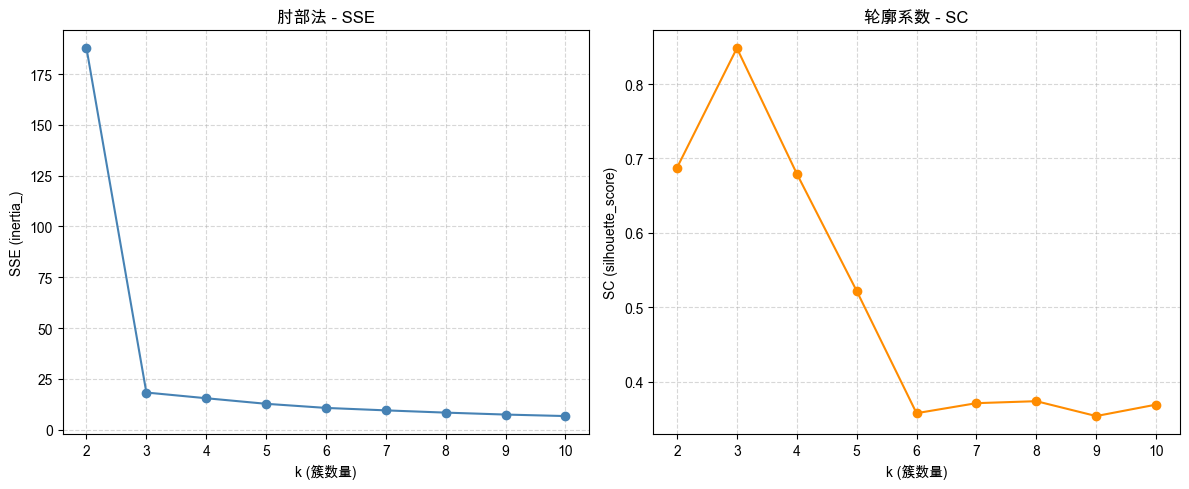

In [3]:
# 5. 肘部法绘图: 同时展示 SSE 与 SC 随 k 变化的曲线
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS"]  # mac 中文显示
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# 左图: SSE 肘部法
axes[0].plot(list(k_range), sse_list, "o-", color = "steelblue")
axes[0].set_xlabel("k (簇数量)")
axes[0].set_ylabel("SSE (inertia_)")
axes[0].set_title("肘部法 - SSE")
axes[0].grid(True, linestyle = "--", alpha = 0.5)

# 右图: 轮廓系数 SC
axes[1].plot(list(k_range), sc_list, "o-", color = "darkorange")
axes[1].set_xlabel("k (簇数量)")
axes[1].set_ylabel("SC (silhouette_score)")
axes[1].set_title("轮廓系数 - SC")
axes[1].grid(True, linestyle = "--", alpha = 0.5)

plt.tight_layout()
plt.show()

最佳 k = 3
SSE = 18.26
SC  = 0.8482
CH  = 4730.17


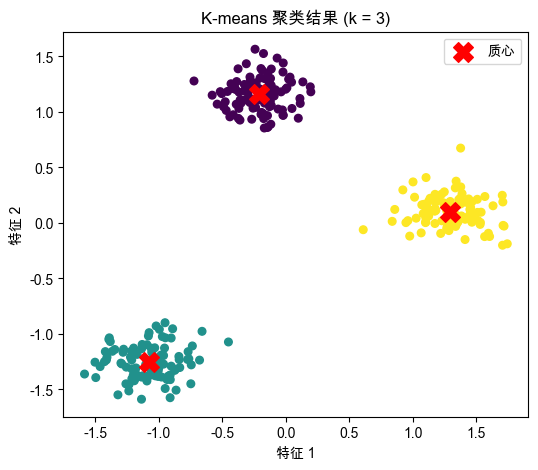

In [4]:
# 6. 根据肘部法与 SC 确定最佳 k (本数据集为 3 个中心), 使用最佳 k 进行最终聚类
best_k = 3
km = KMeans(n_clusters = best_k, random_state = 42, n_init = 10)
y_pred = km.fit_predict(X_scaled)

print(f"最佳 k = {best_k}")
print(f"SSE = {km.inertia_:.2f}")
print(f"SC  = {silhouette_score(X_scaled, y_pred):.4f}")
print(f"CH  = {calinski_harabasz_score(X_scaled, y_pred):.2f}")

# 7. 可视化聚类结果
plt.figure(figsize = (6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c = y_pred, cmap = "viridis", s = 30)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c = "red", marker = "X", s = 200, label = "质心")
plt.xlabel("特征 1")
plt.ylabel("特征 2")
plt.title(f"K-means 聚类结果 (k = {best_k})")
plt.legend()
plt.show()